In [1]:
import jax
import jax.numpy as jnp
import pennylane as qml
from flax import nnx
from functools import partial
import numpy as np
from QNN_jax import initialize_parameters
import jax
jax.config.update("jax_enable_x64", True)
# -------------------------- 第一步：改造量子电路，原生支持Batch输入 --------------------------
def quantum_neural_network(x, params, n_qubits, n_layers):
    """
    兼容Batch的量子电路核心逻辑：
    - x: 输入张量，形状为 (batch_size, n_qubits)（Batch维度在前）
    - params: 量子电路参数，形状为 (n_layers, 2 * n_qubits)
    - 所有量子门操作自动沿Batch维度向量化，无需手动循环
    """
    # 1. 强制将输入转为JAX张量（兼容np.array/其他格式），并确保是二维（batch, n_qubits）
    x = jnp.atleast_2d(x)
    # 校验特征维度（Batch维度不校验，由NNX自动兼容）
    if x.shape[-1] != n_qubits:
        raise ValueError(f"输入特征维度需为{n_qubits}，当前为{x.shape[-1]}")
    
    # 2. 数据编码：向量化RX门（自动兼容Batch）
    # qml.RX支持批量角度输入，会自动为每个Batch样本应用对应角度的门
    for i in range(n_qubits):
        qml.RX(x[:, i] * jnp.pi, wires=i)  # x[:, i] 取所有Batch样本的第i个特征
    
    # 3. 变分层：向量化旋转/纠缠门（Batch维度自动兼容）
    for layer in range(n_layers):
        # 纠缠层（CNOT无参数，Batch不影响）
        for i in range(n_qubits - 1):
            qml.CNOT(wires=[i, i+1])
        qml.Barrier(wires=range(n_qubits))
        # 旋转层：参数向量化，自动适配Batch
        for i in range(n_qubits):
            qml.RX(params[layer, 2*i], wires=i)  # RX参数
            qml.RZ(params[layer, 2*i+1], wires=i)  # RZ参数
    # 4. 测量：返回每个量子比特的期望值

    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

In [2]:
n_qubits = 4
n_layers = 2
dev = qml.device("default.qubit", wires=n_qubits)
# 封装QNode：interface="jax" 确保兼容JAX/NNX的Batch计算
qnode = qml.QNode(quantum_neural_network, dev, interface="jax")
# 测试单个输入
params = initialize_parameters(n_layers, n_qubits)
result = qnode(x=[1,0,1,0], params=params, n_layers=n_layers, n_qubits=n_qubits)
print("单个输入结果:", result)
result

单个输入结果: [Array([0.21062209], dtype=float64), Array([0.09039875], dtype=float64), Array([-0.27025594], dtype=float64), Array([-0.19796214], dtype=float64)]


[Array([0.21062209], dtype=float64),
 Array([0.09039875], dtype=float64),
 Array([-0.27025594], dtype=float64),
 Array([-0.19796214], dtype=float64)]

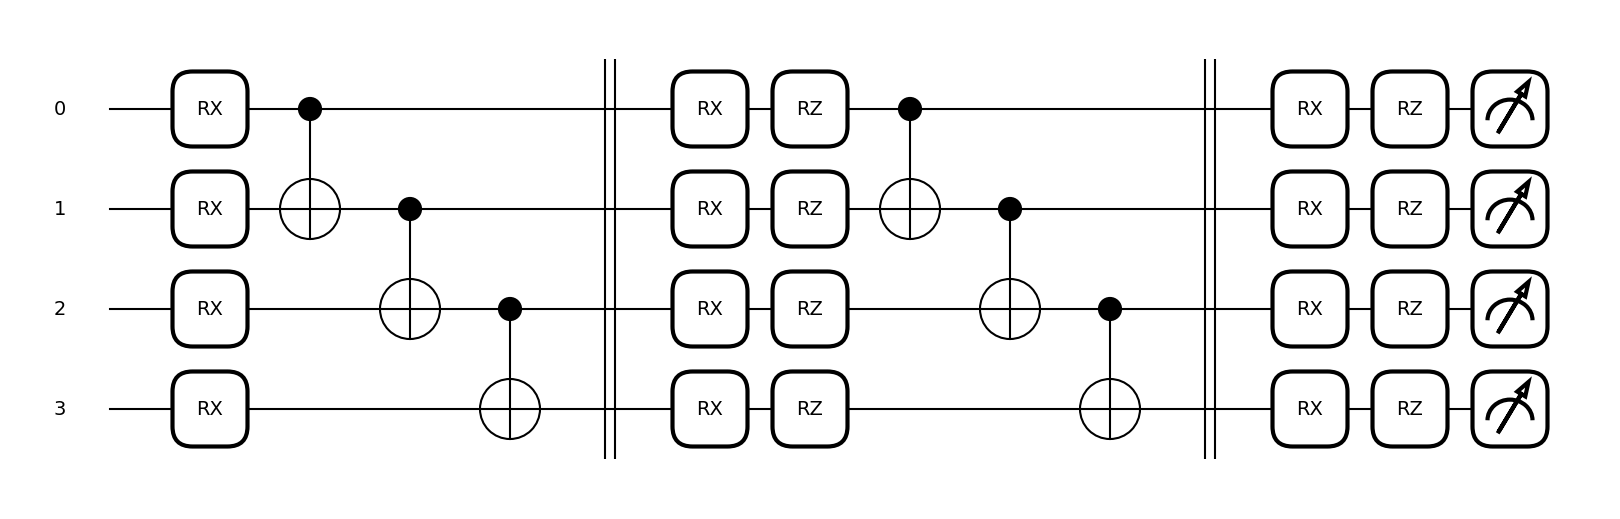

In [3]:
import matplotlib.pyplot as plt
qml.drawer.use_style("black_white")
fig, ax = qml.draw_mpl(qnode)(x=[1,0,1,0],params=initialize_parameters(2,4),n_layers=2,n_qubits=4)
plt.show()

尝试把 QNN jax化

In [4]:
def qnn_circuit(n_qubits:int,n_layers:int):
    dev = qml.device('default.qubit',wires=n_qubits)
    pqc_node = qml.QNode(func=quantum_neural_network,device=dev,interface='jax')
    qnn_node_circuit = partial(pqc_node,n_qubits=n_qubits,n_layers=n_layers)
    return qnn_node_circuit

In [26]:
from flax import nnx
from functools import partial
class QNNLinear(nnx.Module):
    def __init__(self, rngs: nnx.Rngs,n_qubits:int,n_layer:int):
        key = rngs.params()
        # 不存储PRNGKey，直接使用rngs.params()初始化参数
        self.n_qubits,self.n_layer = n_qubits,n_layer
        self.qnn_params = nnx.Param(jax.random.normal(key, (self.n_layer, 2*self.n_qubits), dtype=jnp.float32))
        self.qnn_layer = partial(qnn_circuit, n_qubits=self.n_qubits, n_layers=self.n_layer)()
        self.Linear = nnx.Linear(in_features=self.n_qubits,out_features=self.n_qubits,use_bias=False,rngs=rngs)
        
    
    def __call__(self, s:np.array):
        # 确保输入是JAX数组
        s = jnp.array(s, dtype=jnp.float32)
        # 获取QNN输出
        qnn_output = self.qnn_layer(x=s,params=self.qnn_params) #dtype=float32
        # 将QNN输出转换为float32类型
        #qnn_output = jnp.array(qnn_output, dtype=jnp.float32).reshape(-1,self.n_qubits)
        qnn_output = jnp.stack(qnn_output, axis=1)  # 形状: (batch_size, n_qubits)
        qnn_output = jnp.array(qnn_output, dtype=jnp.float32)
        y = self.Linear(qnn_output)
        y = nnx.relu(y)
        return jnp.sum(y, axis=-1)
    
class QNN_Hybrid(nnx.Module):
    def __init__(self, rngs_real: nnx.Rngs,rngs_imag:nnx.Rngs,n_qubits:int,n_layer:int):
        self.qnn_real = QNNLinear(rngs_real,n_qubits,n_layer)
        self.qnn_imag = QNNLinear(rngs_imag,n_qubits,n_layer)
        
        
    def __call__(self, s:np.array):
        real = self.qnn_real(s)
        imag = self.qnn_imag(s)
        return real + 1j*imag
        
class FFN(nnx.Module):

    def __init__(self, N: int, alpha: int = 1, *, rngs: nnx.Rngs):
        self.alpha = alpha
        self.linear = nnx.Linear(in_features=N, out_features=alpha * N, rngs=rngs,param_dtype=complex)

    def __call__(self, x: jax.Array):
        y = self.linear(x)
        y = nnx.relu(y)
        return jnp.sum(y, axis=-1)
    
class FFN_QNN_Hybrid(nnx.Module):
    def __init__(self, rngs_real: nnx.Rngs,rngs_imag:nnx.Rngs,rngs_ffn:nnx.Rngs,n_qubit:int,n_layer:int,alpha:int):
        self.ffn = FFN(N=n_qubit, alpha=1, rngs=rngs_ffn)
        self.qnn = QNN_Hybrid(rngs_real,rngs_imag,n_qubits,n_layer)
        
    def __call__(self, s:np.array):
        ffn_output = self.ffn(s)
        qnn_output = self.qnn(s)
        return ffn_output + qnn_output
        

In [27]:
model = FFN_QNN_Hybrid(rngs_real=nnx.Rngs(params=0),rngs_imag=nnx.Rngs(params=1),rngs_ffn=nnx.Rngs(params=2),n_qubit=4,n_layer=2,alpha=1)


In [28]:
model(s=[[1,0,1,0],[0,1,0,1]])

Array([0.84335339+0.0481016j, 0.13556612+0.j       ], dtype=complex128)

接下来在$H_2$分子的VMC中尝试使用这个经典-量子混合模型作为 Ansatz

In [29]:
import netket as nk
import numpy as np
import matplotlib.pyplot as plt
import json
from pyscf import gto, scf, fci
import netket.experimental as nkx

# 设置H2分子的几何构型
bond_length = 2.2 # H2平衡键长（埃）
geometry = [
    ('H', (0., 0., 0.)),
    ('H', (bond_length, 0., 0.)),
]

# 创建分子对象，使用STO-3G基组
mol = gto.M(atom=geometry, basis='STO-3G')

# 进行Hartree-Fock计算
mf = scf.RHF(mol).run(verbose=0)
E_hf = mf.e_tot
print(f"Hartree-Fock能量: {E_hf:.8f} Ha")

# 进行FCI计算作为参考
cisolver = fci.FCI(mf)
E_fci, fcivec = cisolver.kernel()
print(f"FCI能量: {E_fci:.8f} Ha")

# 使用NetKet创建哈密顿量
ha = nkx.operator.from_pyscf_molecule(mol)

Hartree-Fock能量: -0.74640135 Ha
FCI能量: -0.94122403 Ha


In [30]:
hi = nk.hilbert.SpinOrbitalFermions(
    n_orbitals=2,  # 总空间轨道数
    s = 1/2,
    n_fermions_per_spin=(1, 1)  # 每种自旋的电子数
)

# 创建采样器 - 使用费米子跳跃采样器
# 对于分子系统，我们使用完整的轨道图（完全连接）
cluster = [(0,1),(2,3)]
#

# g = nk.graph.Graph(edges=[(0,2),(1,3),(2,0),(3,1)])
g = nk.graph.Graph(edges=[(0,1),(2,3)])
# g = nk.graph.Graph(edges=cluster)
sampler = nk.sampler.MetropolisFermionHop(
    hi, graph=g, n_chains=16, spin_symmetric=True, sweep_size=64
)

In [31]:
vstate = nk.vqs.MCState(sampler, model, n_samples=1008)

In [32]:
energy_stats = vstate.expect(ha)
print("能量平均值:", energy_stats.mean.real)
print("统计误差:", energy_stats.error_of_mean.real)
print("局域能量方差:", energy_stats.variance.real)

能量平均值: -0.46458773636626427
统计误差: 0.006114432524353527
局域能量方差: 0.037685375375631075


In [33]:
# 设置优化器
opt = nk.optimizer.Sgd(learning_rate=0.05)
sr = nk.optimizer.SR(diag_shift=0.01)

# 创建VMC驱动器
gs = nk.driver.VMC(ha, opt, variational_state=vstate, preconditioner=sr)

# 运行优化
exp_name = "h2_molecule_qnn_hybrid"

In [34]:
gs.run(200, out=exp_name)

  0%|          | 0/200 [00:00<?, ?it/s]/opt/miniconda3/envs/Neural/lib/python3.11/site-packages/netket/optimizer/qgt/qgt_onthefly.py:139: HolomorphicUndeclaredWarning: 
Defaulting to `holomorphic=False`, but this might lead to increased
computational cost or disabled features. Check if your variational
function is holomorphic, and if so specify `holomorphic=True`as an extra
keyword argument.

To silence this warning, specify the `holomorphic=False/True` keyword
argument.

To numerically check whether your variational function is or not holomorphic
you can use the following snippet:

```python
   vs = nk.vqs.MCState(...)

   nk.utils.is_probably_holomorphic(vs._apply_fun, vs.parameters, vs.samples, vs.model_state)
```

if `nk.utils.is_probably_holomorphic` returns False, then your function is not holomorphic.
If it returns True, it is probably holomorphic.


-------------------------------------------------------
For more detailed informations, visit the following link:
	 https://netket

TypeError: while_loop body function carry input and carry output must have equal types, but they differ:

  * the input carry component value[0]['qnn']['qnn_imag']['Linear']['kernel'] has type float32[4,4] but the corresponding output carry component has type complex128[4,4], so the dtypes do not match;

  * the input carry component value[0]['qnn']['qnn_imag']['qnn_params'] has type float32[2,8] but the corresponding output carry component has type complex128[2,8], so the dtypes do not match;

  * the input carry component value[0]['qnn']['qnn_real']['Linear']['kernel'] has type float32[4,4] but the corresponding output carry component has type complex128[4,4], so the dtypes do not match;

  * the input carry component value[0]['qnn']['qnn_real']['qnn_params'] has type float32[2,8] but the corresponding output carry component has type complex128[2,8], so the dtypes do not match;

  * the input carry component value[1]['qnn']['qnn_imag']['Linear']['kernel'] has type float32[4,4] but th

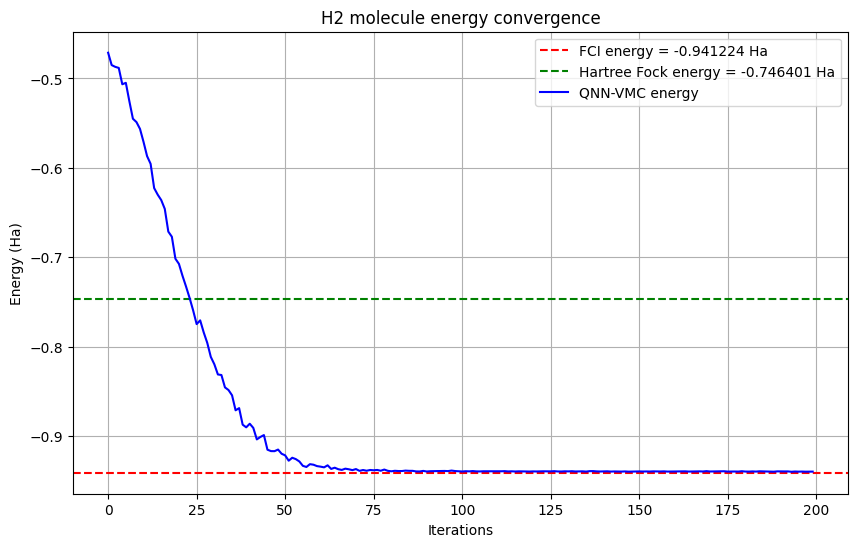

最终VMC能量: -0.93997640 Ha
最终FCI能量: -0.94122403 Ha
最终Hartree-Fock能量: -0.74640135 Ha
与FCI能量误差: 0.00124763 Ha


In [16]:
############## 绘图 #################
# 获取精确对角化能量（FCI能量）
ed_energies = np.array([E_fci])  # H2只有一个基态能量

# 读取日志数据
with open(f"{exp_name}.log") as f:
    data = json.load(f)

x = data["Energy"]["iters"]
y = data["Energy"]["Mean"]['real']

# 绘制能量收敛曲线
plt.figure(figsize=(10, 6))
plt.axhline(ed_energies[0], color="red", linestyle="--", label=f"FCI energy = {E_fci:.6f} Ha")
plt.axhline(E_hf, color="green", linestyle="--", label=f"Hartree Fock energy = {E_hf:.6f} Ha")
plt.plot(x, y, 'b-', label="QNN-VMC energy")
plt.xlabel("Iterations")
plt.ylabel("Energy (Ha)")
plt.title("H2 molecule energy convergence")
plt.legend()
plt.grid(True)
plt.show()

# 打印最终结果
print(f"最终VMC能量: {y[-1]:.8f} Ha")
print(f"最终FCI能量: {E_fci:.8f} Ha")
print(f"最终Hartree-Fock能量: {E_hf:.8f} Ha")
print(f"与FCI能量误差: {abs(y[-1] - E_fci):.8f} Ha")
